# I. Xem trước bộ dữ liệu

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from utils import algorithm
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

pd.set_option('display.max_columns', None)

Đọc file và in ra 05 hàng đầu tiên

In [2]:
data_path = "breast_cancer.csv"
raw = pd.read_csv(data_path)
raw.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Danh sách các thuộc tính
Điền thông tin vào đây

In [3]:
col = ['id','diagnosis','radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean','compactness_mean','concavity_mean','concave_points_mean','symmetry_mean','fractal_dimension_mean','radius_se','texture_se','perimeter_se','area_se','smoothness_se','compactness_se','concavity_se','concave_points_se','symmetry_se','fractal_dimension_se','radius_worst','texture_worst','perimeter_worst','area_worst','smoothness_worst','compactness_worst','concavity_worst','concave_points_worst','symmetry_worst','fractal_dimension_worst']
raw.columns = col

# Hiển thị: Số hàng và kiểu của các features trong bảng
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

Kiểm tra số lượng giá trị không phải kiểu số

In [4]:
raw.isna().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Minh họa trực quan bộ data bằng histogram

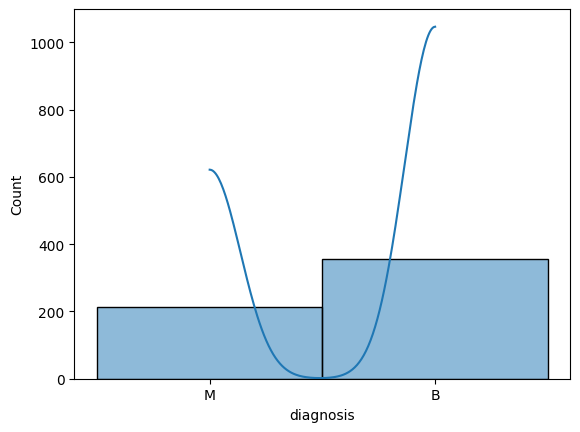

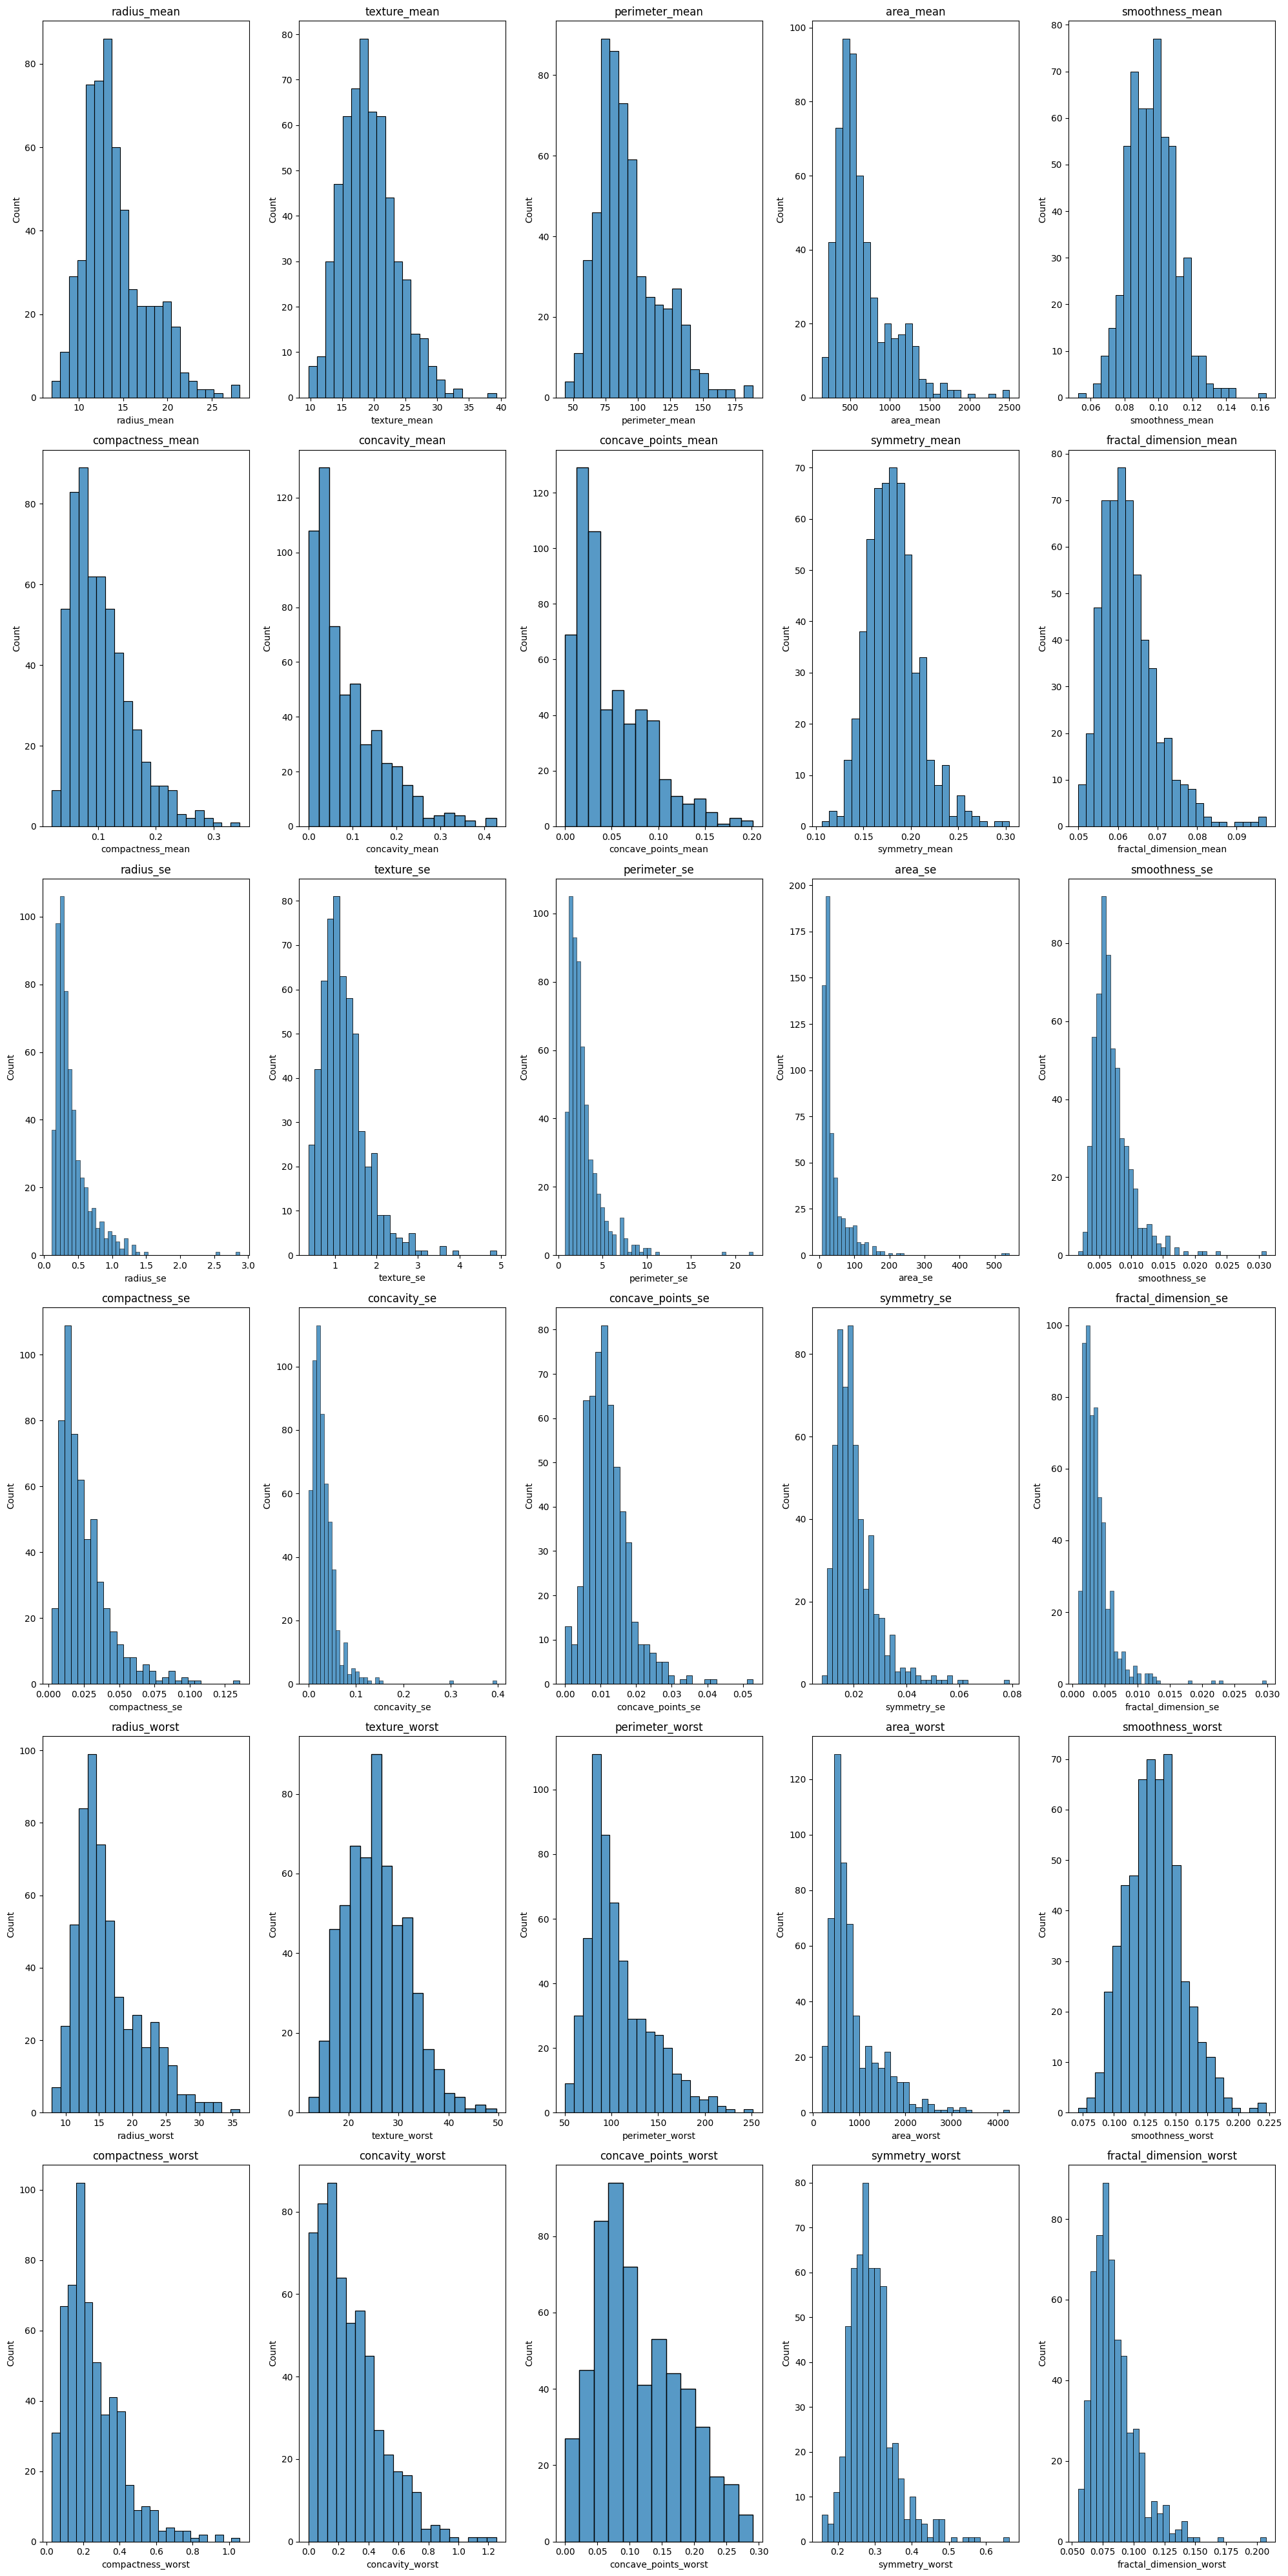

In [5]:
# Minh họa target feature: 'diagnosis'
sns.histplot(raw['diagnosis'], kde='False')

# Minh họa các features còn lại
fig, axes = plt.subplots(6, 5, figsize=(20, 40))
features = raw.columns[-30:]
for i, feature in enumerate(features):
    row = i // 5
    col = i % 5
    sns.histplot(data=raw, x=feature, ax=axes[row, col], kde=False)
    axes[row, col].set_title(feature)

plt.tight_layout()
plt.show()

## II. Chuẩn hóa dữ liệu


Dựa vào bảng xem trước, ta chia các cột thành các nhóm như sau:

In [6]:
drop_cols = [col for col in ['id']] # Cột 'id' không có ý nghĩa trong quá trình học máy
target_col = 'diagnosis'
num_cols = [col for col in raw.columns if col not in drop_cols + [target_col]]
cat_cols = []

### Pipeline cho tiền xử lý

In [7]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

### Tiền xử lý dữ liệu

In [8]:
X = raw.drop(drop_cols + [target_col], axis=1)
y = raw[target_col].map({'M':1,'B':0})

X = preprocessor.fit_transform(X)
df = pd.DataFrame(X, columns=num_cols, index=raw.index)

# gắn nhãn nếu có
if y is not None:
    df[target_col] = y.values

df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,2.489734,-0.565265,2.833031,2.487578,-0.214002,1.316862,0.724026,0.660820,1.148757,0.907083,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015,1
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,0.499255,-0.876244,0.263327,0.742402,-0.605351,-0.692926,-0.440780,0.260162,-0.805450,-0.099444,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190,1
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,1.228676,-0.780083,0.850928,1.181336,-0.297005,0.814974,0.213076,1.424827,0.237036,0.293559,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391,1
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,0.326373,-0.110409,0.286593,-0.288378,0.689702,2.744280,0.819518,1.115007,4.732680,2.047511,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010,1
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,1.270543,-0.790244,1.273189,1.190357,1.483067,-0.048520,0.828471,1.144205,-0.361092,0.499328,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100,1


Các đặc trưng của dữ liệu sau khi đã được chuẩn hóa:

In [9]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
count,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,569.000000,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,569.000000,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,569.000000
mean,-1.373633e-16,6.868164e-17,-1.248757e-16,-2.185325e-16,-8.366672e-16,1.873136e-16,4.995028e-17,-4.995028e-17,1.748260e-16,4.745277e-16,2.372638e-16,-1.123881e-16,-1.123881e-16,-1.311195e-16,-1.529727e-16,1.748260e-16,1.623384e-16,0.000000,8.741299e-17,-6.243785e-18,-8.241796e-16,1.248757e-17,-3.746271e-16,0.000000,-2.372638e-16,-3.371644e-16,7.492542e-17,2.247763e-16,2.622390e-16,-5.744282e-16,0.372583
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,0.483918
min,-2.029648e+00,-2.229249e+00,-1.984504e+00,-1.454443e+00,-3.112085e+00,-1.610136e+00,-1.114873e+00,-1.261820e+00,-2.744117e+00,-1.819865e+00,-1.059924e+00,-1.554264e+00,-1.044049e+00,-7.378291e-01,-1.776065e+00,-1.298098e+00,-1.057501e+00,-1.913447,-1.532890e+00,-1.096968e+00,-1.726901e+00,-2.223994e+00,-1.693361e+00,-1.222423,-2.682695e+00,-1.443878e+00,-1.305831e+00,-1.745063e+00,-2.160960e+00,-1.601839e+00,0.000000
25%,-6.893853e-01,-7.259631e-01,-6.919555e-01,-6.671955e-01,-7.109628e-01,-7.470860e-01,-7.437479e-01,-7.379438e-01,-7.032397e-01,-7.226392e-01,-6.235706e-01,-6.948092e-01,-6.237679e-01,-4.947542e-01,-6.240183e-01,-6.929263e-01,-5.571612e-01,-0.674490,-6.516807e-01,-5.851185e-01,-6.749213e-01,-7.486293e-01,-6.895783e-01,-0.642136,-6.912304e-01,-6.810833e-01,-7.565142e-01,-7.563999e-01,-6.418637e-01,-6.919118e-01,0.000000
50%,-2.150816e-01,-1.046362e-01,-2.359800e-01,-2.951869e-01,-3.489108e-02,-2.219405e-01,-3.422399e-01,-3.977212e-01,-7.162650e-02,-1.782793e-01,-2.922452e-01,-1.974976e-01,-2.866520e-01,-3.477828e-01,-2.203352e-01,-2.810204e-01,-1.990654e-01,-0.140496,-2.194304e-01,-2.299405e-01,-2.690395e-01,-4.351564e-02,-2.859802e-01,-0.341181,-4.684277e-02,-2.695009e-01,-2.182321e-01,-2.234689e-01,-1.274095e-01,-2.164441e-01,0.000000
75%,4.693926e-01,5.841756e-01,4.996769e-01,3.635073e-01,6.361990e-01,4.938569e-01,5.260619e-01,6.469351e-01,5.307792e-01,4.709834e-01,2.660996e-01,4.665523e-01,2.430307e-01,1.067726e-01,3.683553e-01,3.896541e-01,3.367521e-01,0.472657,3.556925e-01,2.886421e-01,5.220158e-01,6.583411e-01,5.402790e-01,0.357589,5.975448e-01,5.396688e-01,5.311411e-01,7.125100e-01,4.501382e-01,4.507624e-01,1.000000
max,3.971288e+00,4.651889e+00,3.976130e+00,5.250529e+00,4.770911e+00,4.568425e+00,4.243589e+00,3.927930e+00,4.484751e+00,4.910919e+00,8.906909e+00,6.655279e+00,9.461986e+00,1.104184e+01,8.029999e+00,6.143482e+00,1.207268e+01,6.649601,7.071917e+00,9.851593e+00,4.094189e+00,3.885905e+00,4.287337e+00,5.930172,3.955374e+00,5.112877e+00,4.700669e+00,2.685877e+00,6.046041e+00,6.846856e+00,1.000000


### Ma trận tương quan

<Axes: >

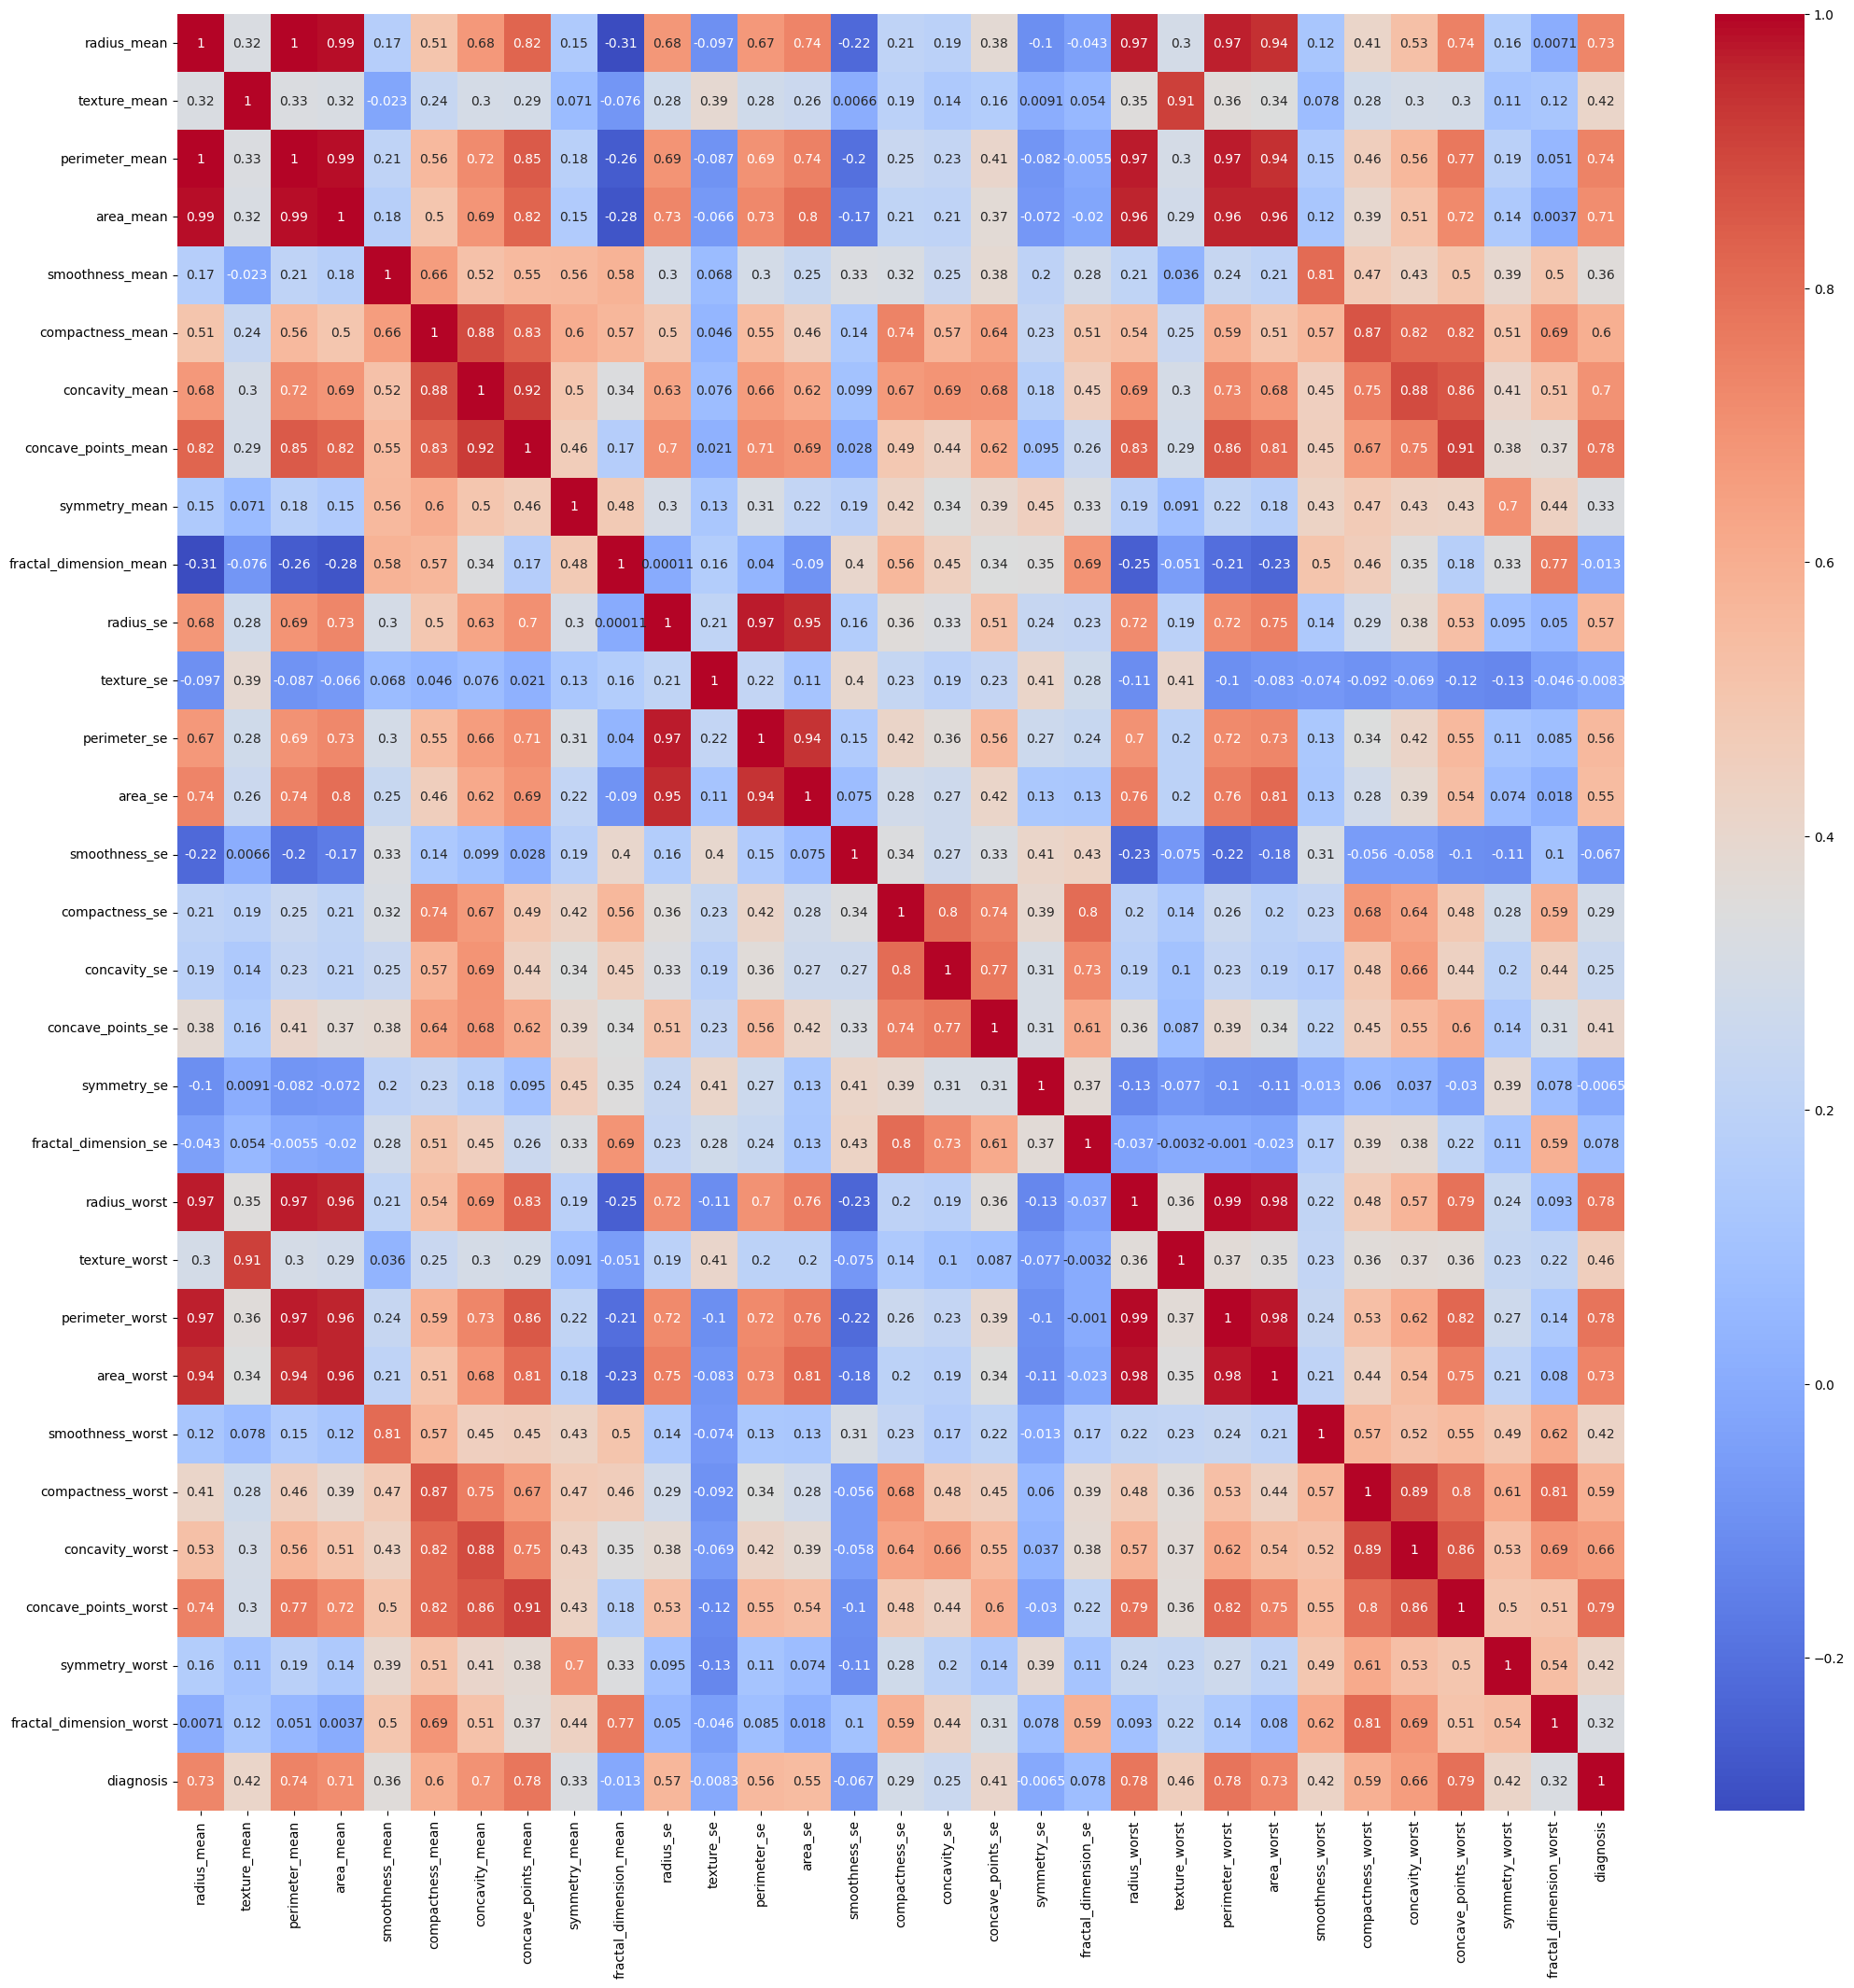

In [10]:
correlation = df.corr()
plt.figure(figsize=(25,25))
sns.heatmap(correlation, annot=True, cmap='coolwarm')

Chọn ra những features có correlation cao (trị tuyệt đối > 0.75) đối với target.

<Figure size 1000x800 with 0 Axes>

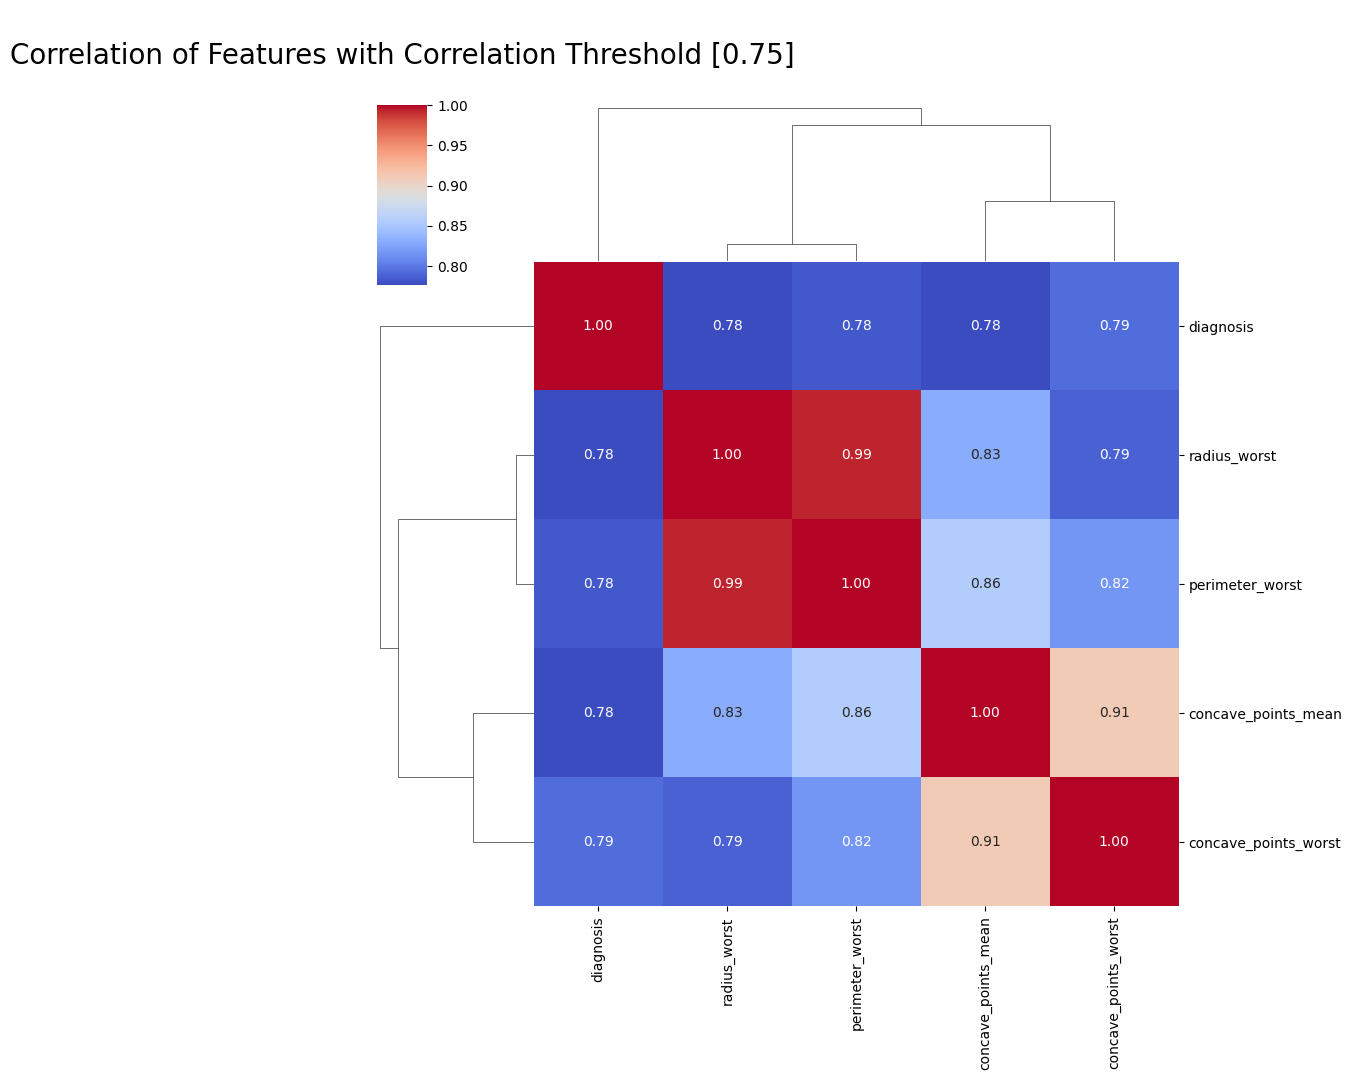

In [11]:
threshold = 0.75
filter = np.abs(correlation["diagnosis"] > threshold)
correlation_features = correlation.columns[filter].tolist()
plt.figure(figsize=(10,8))
sns.clustermap(df[correlation_features].corr(), annot = True, fmt = ".2f", cmap='coolwarm')
plt.title("\nCorrelation of Features with Correlation Threshold [0.75]\n",fontsize=20)
plt.show()

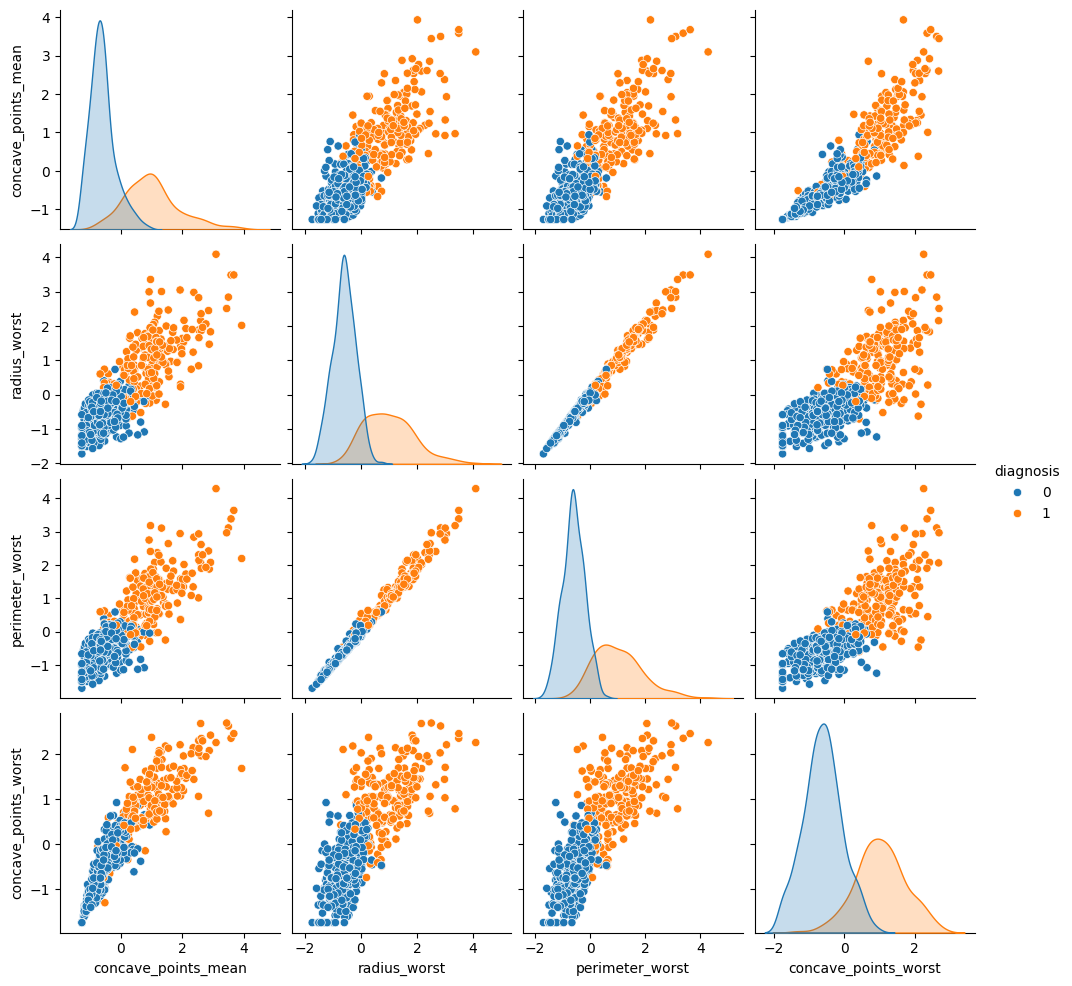

In [12]:
sns.pairplot(df[correlation_features], diag_kind = "kde",  hue="diagnosis")
plt.show()

## III. Chia tập dữ liệu

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)
Algorithm = ['KNeighborsClassifier','LogisticRegression', 'SVM', 'Naive Bayes', 'RandomForest', 'VotingClassifier']
Accuracy = [] # Lưu trữ độ chính xác

## IV. Huấn luyện và Kiểm thử (Train and Test)

Phương pháp huấn luyện mô hình:
- Sử dụng Grid Search duyệt qua các bộ tham số để tìm ra bộ tối ưu nhất.
- Sử dụng chính bộ tham số tối ưu vừa tìm được để kiểm thử trên tập X_test, cho ra y_pred.
- So sánh giữa y_pred và y_test, từ đó đánh giá tương quan độ chính xác của mô hình.

### 1. k-NN

In [16]:
# Thiết lập không gian tham số cho mô hình KNN
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],  # Số lượng hàng xóm lân cận (K)
    'weights': ['uniform', 'distance'],  # Trọng số hàng xóm (cân nhắc khoảng cách hoặc không)
    'metric': ['euclidean', 'manhattan', 'minkowski']  # Đo lường khoảng cách
}

# Tìm kiếm tham số tối ưu
# Với scoring='f1': Sử dụng F1-score của lớp dương.
# Với scoring=make_scorer(f1_score, average='weighted'): Sử dụng weighted average F1-score.
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=10, scoring=make_scorer(f1_score, average='weighted'))  # cv = 10 tức là k-fold ở đây k = 10
grid_search.fit(X_train, y_train)

# Kết quả
print("Best Parameters:", grid_search.best_params_)
knn_neighbors = grid_search.best_params_.get('n_neighbors')
knn_weights = grid_search.best_params_.get('weights')
knn_metric = grid_search.best_params_.get('metric')

print(knn_neighbors, knn_weights, knn_metric)

print("Best cross-validated score:", grid_search.best_score_)

# Sử dụng tham số tốt nhất để huấn luyện lại mô hình
best_knn_model = grid_search.best_estimator_
y_pred_optimized = best_knn_model.predict(X_test)

# Đánh giá mô hình tối ưu
print("\nConfusion Matrix (Optimized):")
print(confusion_matrix(y_test, y_pred_optimized))

print("\nClassification Report (Optimized):")
print(classification_report(y_test, y_pred_optimized))

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
3 uniform euclidean
Best cross-validated score: 0.9746891549498242

Confusion Matrix (Optimized):
[[106   1]
 [  7  57]]

Classification Report (Optimized):
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       107
           1       0.98      0.89      0.93        64

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171



confusion matrix


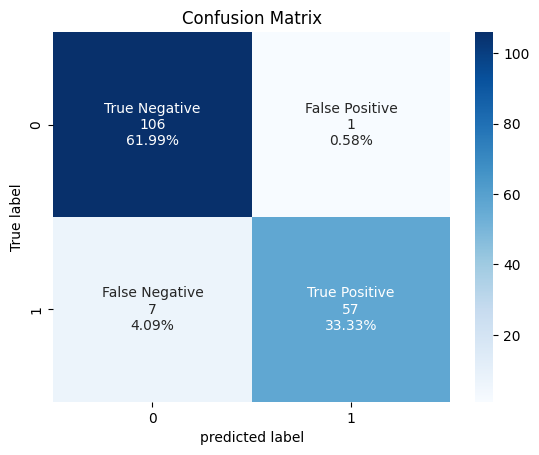

[[106   1]
 [  7  57]]
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       107
           1       0.98      0.89      0.93        64

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171

weighted_f1_score :  95.27039157755293


In [17]:
model_1 = KNeighborsClassifier(n_neighbors=knn_neighbors, weights=knn_weights, metric=knn_metric)
algorithm(model_1, X_train, y_train, X_test, y_test, Accuracy)

### 2. Logistic Regression

In [18]:
import warnings
warnings.filterwarnings('ignore')

param_grid = [
    {'solver': ['lbfgs'], 'penalty': ['l2', None], 'C': [0.01,0.1,1,10,100], 'max_iter':[100,200,500]},
    {'solver': ['liblinear'], 'penalty': ['l1','l2'], 'C': [0.01,0.1,1,10,100], 'max_iter':[100,200,500]},
    {'solver': ['saga'], 'penalty': ['l1','l2','elasticnet', None], 
     'C': [0.01,0.1,1,10,100], 'max_iter':[100,200,500],
     'l1_ratio': [0.2, 0.5, 0.8]}  # Chỉ dùng khi penalty='elasticnet'
]

# verbose=1: Hiển thị quá trình tìm kiếm tham số tốt nhất
grid_search = GridSearchCV(estimator=LogisticRegression(), param_grid=param_grid, cv=10, scoring=make_scorer(f1_score, average='weighted'), verbose=1)
grid_search.fit(X_train, y_train)

# Lấy kết quả tốt nhất
best_model = grid_search.best_estimator_
LR_C = grid_search.best_params_.get('C')
LR_penalty = grid_search.best_params_.get('penalty')
LR_solver = grid_search.best_params_.get('solver')
LR_max_iter = grid_search.best_params_.get('max_iter')
print("Best Parameters:", grid_search.best_params_)
print("Best cross-validated score:", grid_search.best_score_)

# Sử dụng tham số tốt nhất để huấn luyện lại mô hình
best_LR_model = grid_search.best_estimator_
y_pred_optimized = best_LR_model.predict(X_test)

# Đánh giá mô hình tối ưu
print("\nConfusion Matrix (Optimized):")
print(confusion_matrix(y_test, y_pred_optimized))

print("\nClassification Report (Optimized):")
print(classification_report(y_test, y_pred_optimized))

Fitting 10 folds for each of 240 candidates, totalling 2400 fits
Best Parameters: {'C': 1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validated score: 0.992413552315513

Confusion Matrix (Optimized):
[[106   1]
 [  6  58]]

Classification Report (Optimized):
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       107
           1       0.98      0.91      0.94        64

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



confusion matrix


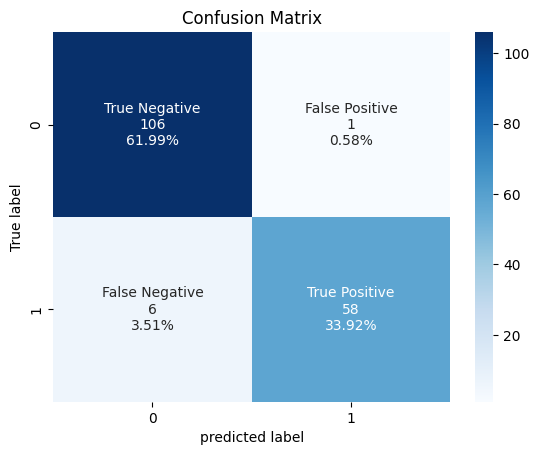

[[106   1]
 [  6  58]]
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       107
           1       0.98      0.91      0.94        64

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171

weighted_f1_score :  95.86996038189173


In [19]:
# LogisticRegression(tham số mặc định): C = 1.0, penalty = 'l2', solver = 'lbfgs', max_iter = 100
model_2 = LogisticRegression(C = LR_C, penalty = LR_penalty, solver = LR_solver, max_iter = LR_max_iter)
algorithm(model_2, X_train, y_train, X_test, y_test, Accuracy)

## 3. SVM

In [20]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 10],
    'kernel': ['rbf', 'poly', 'sigmoid'] #thêm 'linear', 'poly', 'sigmoid' nếu muốn thử các kernel khác 
}

# Tìm kiếm tham số tối ưu
# f1 ở đây cụ thể là weighted avg f1-score đúng không ? 
grid_search = GridSearchCV(SVC(), param_grid, cv=10     , scoring=make_scorer(f1_score, average='weighted')) # cv = 5 tức là k-fold ở đây k = 5
grid_search.fit(X_train, y_train)

# Kết quả
print("Best Parameters:", grid_search.best_params_)
svm_C = grid_search.best_params_.get('C')
svm_gamma = grid_search.best_params_.get('gamma')
svm_kernel = grid_search.best_params_.get('kernel')

print(svm_C, svm_gamma, svm_kernel)

print("Best cross-validated score:", grid_search.best_score_)
# Sử dụng tham số tốt nhất để huấn luyện lại mô hình
best_svm_model = grid_search.best_estimator_
y_pred_optimized = best_svm_model.predict(X_test)

# Đánh giá mô hình tối ưu
print("\nConfusion Matrix (Optimized):")
print(confusion_matrix(y_test, y_pred_optimized))

print("\nClassification Report (Optimized):")
print(classification_report(y_test, y_pred_optimized))

Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
10 0.01 rbf
Best cross-validated score: 0.9924097710477223

Confusion Matrix (Optimized):
[[106   1]
 [  6  58]]

Classification Report (Optimized):
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       107
           1       0.98      0.91      0.94        64

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



rbf
10
0.01
confusion matrix


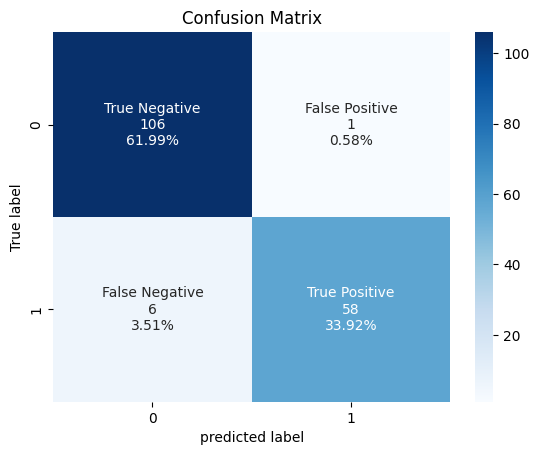

[[106   1]
 [  6  58]]
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       107
           1       0.98      0.91      0.94        64

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171

weighted_f1_score :  95.86996038189173


In [21]:
model_3 = SVC(kernel=svm_kernel, C=svm_C, gamma=svm_gamma, random_state=30)
print(model_3.kernel)
print(model_3.C)
print(model_3.gamma)
algorithm(model_3, X_train, y_train, X_test, y_test, Accuracy)

## 4. Naive Bayes

In [22]:
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]  # Giá trị var_smoothing cho GaussianNB
}

# Tìm kiếm tham số tối ưu
# Với scoring=make_scorer(f1_score, average='weighted'): Sử dụng weighted average F1-score.
grid_search = GridSearchCV(GaussianNB(), param_grid, cv=10, scoring=make_scorer(f1_score, average='weighted'))  # cv = 5 tức là k-fold ở đây k = 5
grid_search.fit(X_train, y_train)

# Kết quả
print("Best Parameters:", grid_search.best_params_)
NB_var_smoothing = grid_search.best_params_.get('var_smoothing')
print("Best cross-validated score:", grid_search.best_score_)

# Sử dụng tham số tốt nhất để huấn luyện lại mô hình
best_NB_model = grid_search.best_estimator_
y_pred_optimized = best_NB_model.predict(X_test)

# Đánh giá mô hình tối ưu
print("\nConfusion Matrix (Optimized):")
print(confusion_matrix(y_test, y_pred_optimized))

print("\nClassification Report (Optimized):")
print(classification_report(y_test, y_pred_optimized))

Best Parameters: {'var_smoothing': 1e-09}
Best cross-validated score: 0.9346466341338482

Confusion Matrix (Optimized):
[[105   2]
 [ 10  54]]

Classification Report (Optimized):
              precision    recall  f1-score   support

           0       0.91      0.98      0.95       107
           1       0.96      0.84      0.90        64

    accuracy                           0.93       171
   macro avg       0.94      0.91      0.92       171
weighted avg       0.93      0.93      0.93       171



confusion matrix


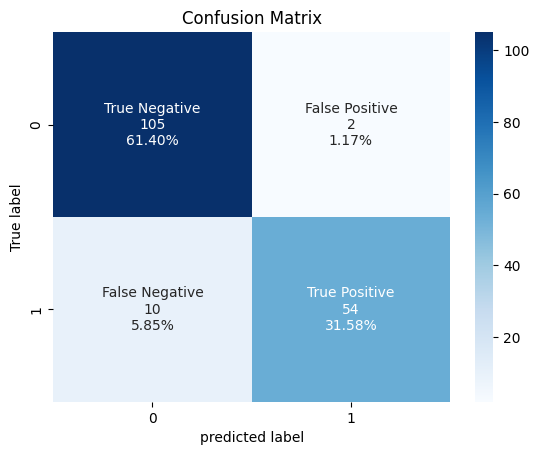

[[105   2]
 [ 10  54]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.95       107
           1       0.96      0.84      0.90        64

    accuracy                           0.93       171
   macro avg       0.94      0.91      0.92       171
weighted avg       0.93      0.93      0.93       171

weighted_f1_score :  92.8749802434013


In [23]:
model_4 = GaussianNB(var_smoothing=NB_var_smoothing)
algorithm(model_4, X_train, y_train, X_test, y_test, Accuracy)

## 5. Random Forest

In [24]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'oob_score': [True, False],   # oob_score chỉ có tác dụng nếu bootstrap=True
    'class_weight': ['balanced', 'balanced_subsample']
}

# Khởi tạo mô hình Random Forest
rf = RandomForestClassifier(random_state=42)

# Khởi tạo GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=10, scoring=make_scorer(f1_score, average='weighted'), n_jobs=-1)

# Huấn luyện GridSearchCV trên dữ liệu huấn luyện
grid_search.fit(X_train, y_train)

# Kết quả
print("Best parameters found: ", grid_search.best_params_)
RF_bootstrap = grid_search.best_params_['bootstrap']
RF_class_weight = grid_search.best_params_['class_weight']
RF_max_depth = grid_search.best_params_['max_depth']
RF_max_features = grid_search.best_params_['max_features']
RF_n_estimators = grid_search.best_params_['n_estimators']
RF_oob_score = grid_search.best_params_['oob_score']

print("Best cross-validation score: ", grid_search.best_score_)

Best parameters found:  {'bootstrap': False, 'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'log2', 'n_estimators': 200, 'oob_score': False}
Best cross-validation score:  0.974891177403368


confusion matrix


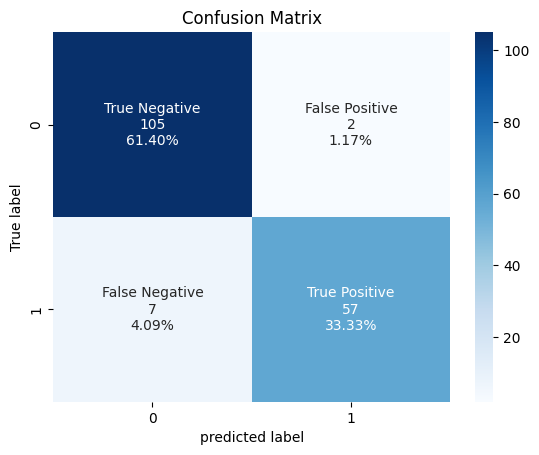

[[105   2]
 [  7  57]]
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       107
           1       0.97      0.89      0.93        64

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171

weighted_f1_score :  94.68994906243223


In [25]:
model_5 = RandomForestClassifier(
    bootstrap=RF_bootstrap,
    class_weight=RF_class_weight,
    max_depth=RF_max_depth,
    max_features=RF_max_features,
    n_estimators=RF_n_estimators,
    oob_score=RF_oob_score
)

algorithm(model_5, X_train, y_train, X_test, y_test, Accuracy)

### 6*. Ensemble: Voting Classifier

confusion matrix


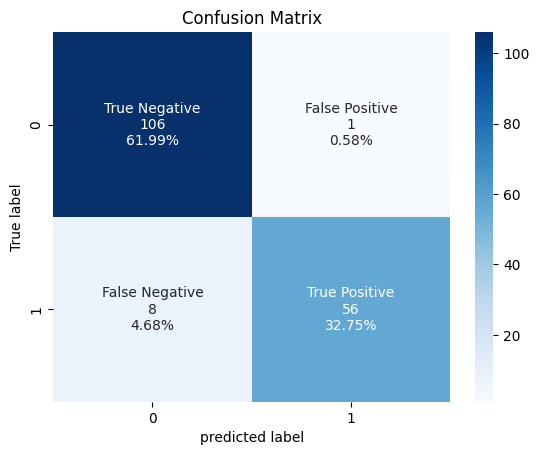

[[106   1]
 [  8  56]]
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       107
           1       0.98      0.88      0.93        64

    accuracy                           0.95       171
   macro avg       0.96      0.93      0.94       171
weighted avg       0.95      0.95      0.95       171

weighted_f1_score :  94.66795518019835


In [26]:
# voting = 'hard': nhãn cuối cùng được chọn dựa trên số phiếu bầu, tức là số lượng mô hình học máy đồng thuận
model_6 = VotingClassifier(estimators=[('kNN', model_1), ('LR', model_2), ('SVM', model_3), ('NB', model_4), ('RF', model_5)], voting='hard')
algorithm(model_6, X_train, y_train, X_test, y_test, Accuracy)

In [27]:
print(Accuracy)

[95.27039157755293, 95.86996038189173, 95.86996038189173, 92.8749802434013, 94.68994906243223, 94.66795518019835]


In [28]:
score = pd.DataFrame({'Algorithm': Algorithm, 'Weighted_f1': Accuracy })
score

,Algorithm,Weighted_f1
0,KNeighborsClassifier,95.270392
1,LogisticRegression,95.869960
2,SVM,95.869960
3,Naive Bayes,92.874980
4,RandomForest,94.689949
5,VotingClassifier,94.667955


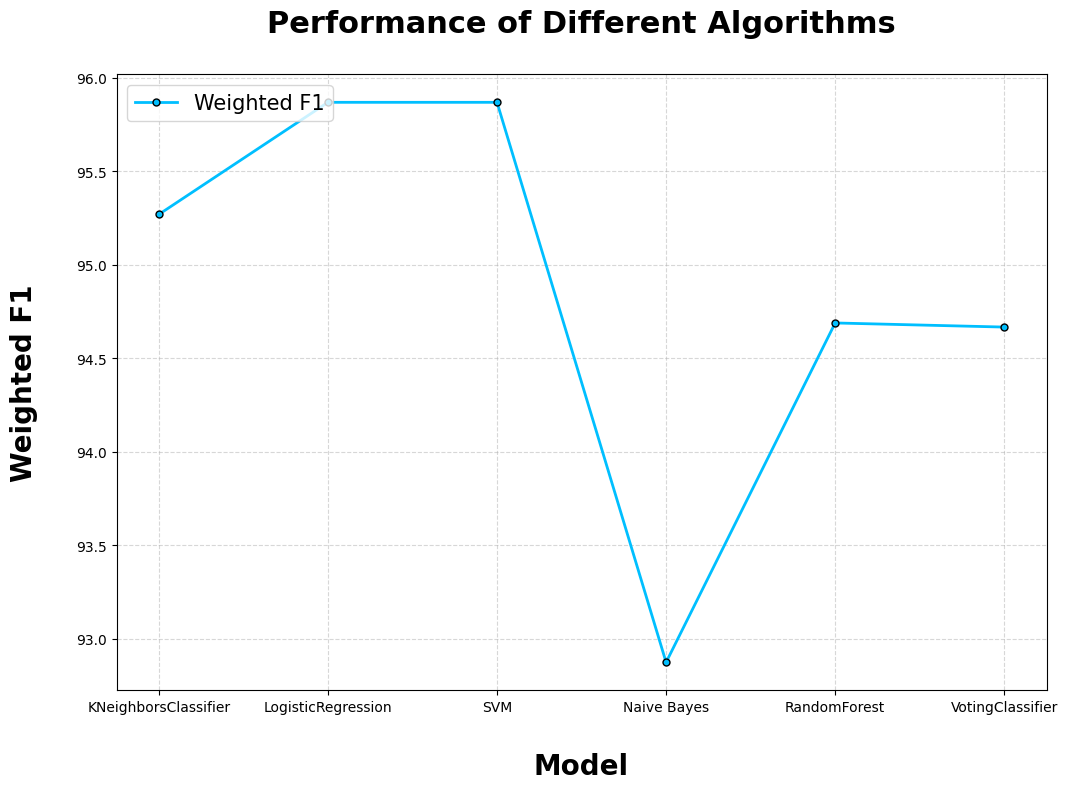

In [29]:
# Tạo hình vẽ với kích thước lớn hơn
fig = plt.figure(figsize=(12,8))

# Vẽ đồ thị với màu sắc và kiểu marker khác
plt.plot(score.Algorithm, score.Weighted_f1, 
         label='Weighted F1', 
         lw=2, color='deepskyblue', # lw = line width là độ dày của đường trong biểu đồ
         marker='o', markersize=5, # marker='o' là kiểu marker hình tròn, markersize=5 là kích thước của marker
         markeredgewidth=1, markeredgecolor='black')

# Thêm lưới (grid)
plt.grid(True, linestyle='--', alpha=0.5)

# Thêm legend
plt.legend(fontsize=15, loc='upper left')

# Đặt nhãn cho trục X và Y
plt.xlabel('\nModel', fontsize=20, fontweight='bold')
plt.ylabel('Weighted F1\n', fontsize=20, fontweight='bold')

# Thêm tiêu đề cho biểu đồ
plt.title('Performance of Different Algorithms\n', fontsize=22, fontweight='bold')

# Hiển thị biểu đồ
plt.show()